<a href="https://colab.research.google.com/github/AshleyMutisya/AI-for-government-policy-assignment-/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Name-Ethnicity Classification using Logistic Regression

Model: TF-IDF character n-grams + Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

print("✓ All libraries loaded")

✓ All libraries loaded


Dataset has 10 nationality groups, each group contains exactly 20 names, ensuring no single nationality dominates the training data.

In [ ]:
data = {
    'british':   ['james smith','oliver johnson','harry williams','george jones','charlie brown',
                  'emily smith','jessica jones','sophie williams','lily taylor','grace evans',
                  'edward moore','henry martin','oscar lee','noah thompson','alfie harris',
                  'isla clark','poppy robinson','ruby walker','daisy hall','freya wilson'],
    'indian':    ['arjun sharma','rahul verma','amit kumar','vijay patel','suresh singh',
                  'priya sharma','neha patel','pooja verma','sunita singh','rani gupta',
                  'karan malhotra','nikhil chopra','varun kapoor','akash bose','ravi nair',
                  'divya reddy','shreya iyer','nisha pillai','smita nair','lakshmi krishnan'],
    'nigerian':  ['abubakar ibrahim','chukwuemeka okonkwo','babatunde adeyemi','emeka okafor','femi adesanya',
                  'ngozi adichie','amaka obi','chioma okeke','funke akindele','yetunde abiodun',
                  'biodun olatunji','segun awolowo','rotimi fasan','wale adeniji','dare omole',
                  'bukola saraki','shade thomas','toyin ojora','jumoke oladele','bimpe adeola'],
    'chinese':   ['wei zhang','fang li','jing wang','lei liu','yang chen',
                  'li mei zhang','xiu ying li','yan wang','hong liu','mei chen',
                  'zhen guo','jun cao','peng luo','tao he','sheng ma',
                  'ling huang','yun zheng','rui liang','qian tang','shan dong'],
    'polish':    ['jan kowalski','piotr nowak','andrzej wisniewski','marek wojcik','krzysztof kowalczyk',
                  'anna kowalska','maria nowak','katarzyna wisniewska','malgorzata wojcik','agnieszka kowalczyk',
                  'lukasz pawlak','rafal kubiak','mateusz adamski','bartlomiej olejnik','szymon bak',
                  'monika pietrzak','karolina grabowska','justyna mazur','patrycja walczak','sylwia michalak'],
    'pakistani': ['muhammad ali','ahmed khan','ali hassan','usman malik','bilal ahmed',
                  'fatima ali','ayesha khan','zainab hassan','mariam malik','sana ahmed',
                  'imran chaudhry','tariq mahmood','shahid nawaz','nasir hussain','khalid baig',
                  'bushra chaudhry','saima mahmood','tahira nawaz','rubina hussain','fozia baig'],
    'german':    ['hans muller','peter schmidt','michael schneider','thomas fischer','andreas weber',
                  'anna muller','petra schmidt','sabine schneider','claudia fischer','angela weber',
                  'lukas krause','felix hoffmann','jonas klein','florian wolf','tobias schroeder',
                  'lena krause','hannah hoffmann','laura klein','julia wolf','katharina schroeder'],
    'french':    ['jean dupont','pierre martin','paul bernard','louis thomas','henry robert',
                  'marie dupont','sophie martin','camille bernard','claire thomas','julie robert',
                  'alexandre laurent','sebastien simon','christophe michel','gabriel lefebvre','mathieu roux',
                  'aurelie laurent','nathalie simon','isabelle michel','valerie lefebvre','stephanie roux'],
    'irish':     ['sean murphy','patrick kelly','michael ryan','john o brien','james walsh',
                  'mary murphy','aoife kelly','siobhan ryan','niamh o brien','ciara walsh',
                  'conor mccarthy','eoin fitzgerald','liam o connor','cian gallagher','darragh quinn',
                  'clodagh mccarthy','grainne fitzgerald','deirdre o connor','maeve gallagher','fionnuala quinn'],
    'romanian':  ['ion popescu','gheorghe ionescu','mihai popa','vasile radu','andrei stan',
                  'maria popescu','elena ionescu','ioana popa','cristina radu','alexandra stan',
                  'vlad dumitrescu','radu mihalache','cosmin dragomir','lucian marinescu','catalin barbu',
                  'simona dumitrescu','ana mihalache','corina dragomir','laura marinescu','raluca barbu'],
}

records = []
for nationality, names in data.items():
    for name in names:
        records.append({'name': name, 'nationality': nationality})

df = pd.DataFrame(records)
print(f"✓ Dataset created: {len(df)} names, {df['nationality'].nunique()} nationalities")
print(df['nationality'].value_counts())

✓ Dataset created: 200 names, 10 nationalities
nationality
british      20
indian       20
nigerian     20
chinese      20
polish       20
pakistani    20
german       20
french       20
irish        20
romanian     20
Name: count, dtype: int64


Feature Extraction and Train/Test Split

Names are converted into numerical features using TF-IDF with character n-grams. The dataset is split into 80% training and 20% test sets

In [ ]:
X = df['name'].values
y = df['nationality'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=50000, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"✓ Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"✓ Feature matrix shape: {X_train_vec.shape}")

✓ Train size: 160 | Test size: 40
✓ Feature matrix shape: (160, 2425)


We trained a Logistic Regression classifier using the multinomial setting, which handles multi-class prediction across all 10 nationality groups simultaneously. Logistic Regression was chosen as our baseline because it is fast and directly comparable to the more complex CNN-LSTM deep learning model used in similar studies.

In [ ]:
clf = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', multi_class='multinomial', random_state=42)
clf.fit(X_train_vec, y_train)
print("✓ Model trained")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✓ Model trained


The classification report shows precision,recall, and F1-score for each nationality group alongside overall accuracy. Recall is used as the primary fairness metric, as it measures what proportion of each group's names were correctly identified.

In [ ]:
y_pred = clf.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print("\nClassification Report:")
print("="*65)
print(classification_report(y_test, y_pred, target_names=class_names))

Overall Accuracy: 0.8500 (85.0%)

Classification Report:
              precision    recall  f1-score   support

     british       0.75      0.75      0.75         4
     chinese       1.00      0.75      0.86         4
      french       0.67      0.50      0.57         4
      german       0.80      1.00      0.89         4
      indian       1.00      0.50      0.67         4
       irish       1.00      1.00      1.00         4
    nigerian       0.57      1.00      0.73         4
   pakistani       1.00      1.00      1.00         4
      polish       1.00      1.00      1.00         4
    romanian       1.00      1.00      1.00         4

    accuracy                           0.85        40
   macro avg       0.88      0.85      0.85        40
weighted avg       0.88      0.85      0.85        40



This chart visualises accuracy broken down by nationality group, sorted from lowest to highest. Groups shown in red performed below average and groups in green perform above it. This is the core fairness visualisation of our analysis.

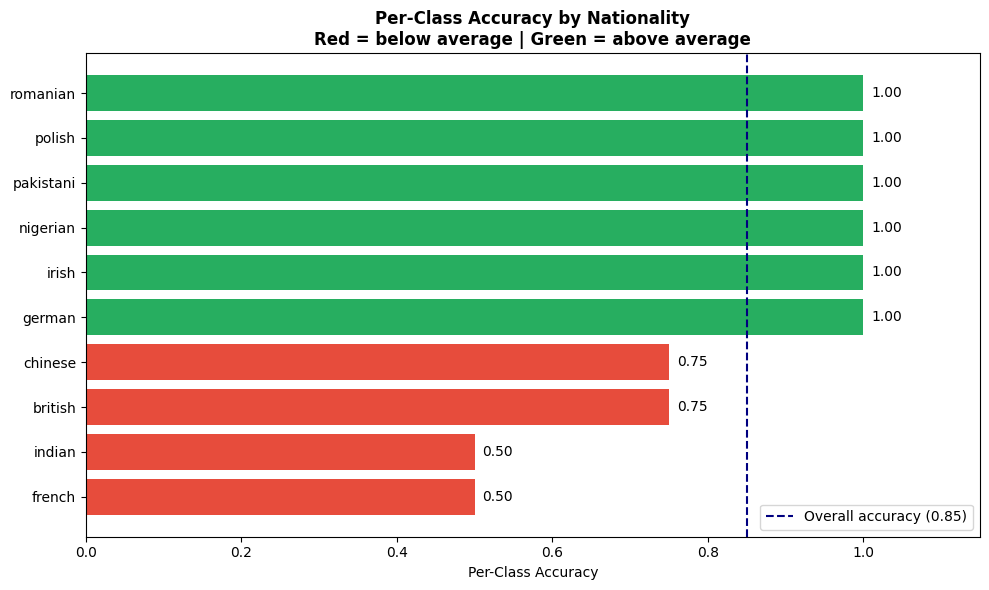

✓ Chart saved


In [ ]:
from sklearn.metrics import classification_report
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

classes = list(class_names)
scores = [report_dict[c]['recall'] for c in classes]
sorted_pairs = sorted(zip(scores, classes))
sorted_scores, sorted_classes = zip(*sorted_pairs)
colors = ['#e74c3c' if s < accuracy else '#27ae60' for s in sorted_scores]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sorted_classes, sorted_scores, color=colors)
ax.axvline(x=accuracy, color='navy', linestyle='--', linewidth=1.5, label=f'Overall accuracy ({accuracy:.2f})')
ax.set_xlabel('Per-Class Accuracy')
ax.set_title('Per-Class Accuracy by Nationality\nRed = below average | Green = above average', fontweight='bold')
ax.set_xlim(0, 1.15)
ax.legend()
for bar, score in zip(bars, sorted_scores):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.2f}', va='center')
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150)
plt.show()
print("✓ Chart saved")

The confusion matrix shows which nationalities the model confuses with each other. Each row represents the true nationality, each column represents the predicted nationality. A perfect classifier would show 1.0 along the diagonal and 0.0 everywhere else. Off-diagonal values reveal systematic misclassification patterns for example, if Pakistani names are frequently predicted as Indian, this suggests the model conflates these groups based on shared patterns, which carries societal implications.

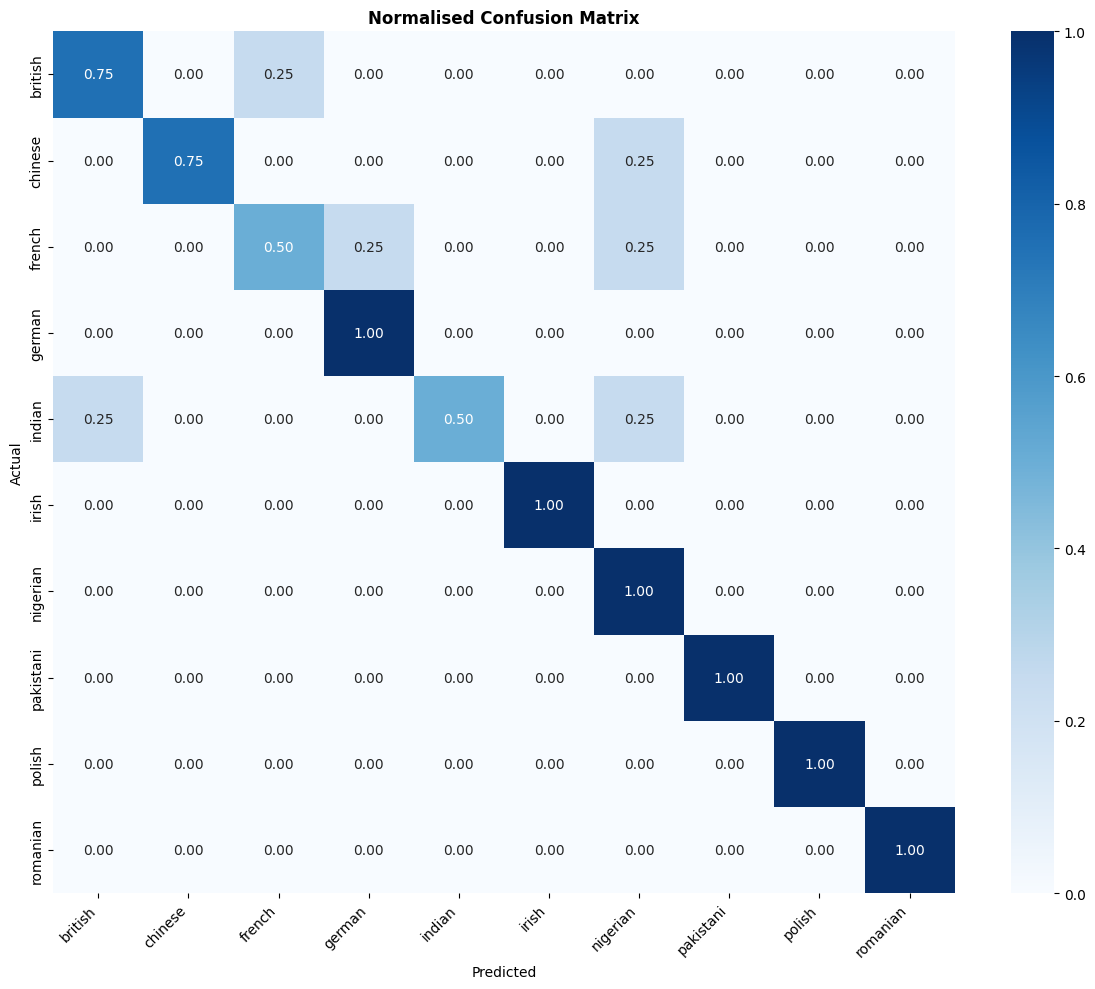

✓ Confusion matrix saved


In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred, normalize='true'),
            annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Normalised Confusion Matrix', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✓ Confusion matrix saved")

We tested the model on six individual names, replicating the original example from Schraagen et al (2022). The confidence score shown is the model's probability for its top prediction, indicating how certain it is in each classification.

In [ ]:
test_names = ['andrew smith', 'abubakar ibrahim', 'priya sharma',
              'wei zhang', 'jan kowalski', 'marie dupont']

test_vec = vectorizer.transform(test_names)
preds = label_encoder.inverse_transform(clf.predict(test_vec))
probs = clf.predict_proba(test_vec)

print(f"{'Name':<25} {'Predicted':<15} {'Confidence'}")
print("-"*55)
for name, pred, prob in zip(test_names, preds, probs):
    print(f"{name:<25} {pred:<15} {prob.max():.1%}")

Name                      Predicted       Confidence
-------------------------------------------------------
andrew smith              british         16.9%
abubakar ibrahim          nigerian        22.9%
priya sharma              indian          34.1%
wei zhang                 chinese         36.7%
jan kowalski              polish          33.7%
marie dupont              french          34.5%
